## Import libraries

In [1]:
import os
import re
import time
import warnings
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import shap
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix)

## Configuration

In [2]:
sns.set_style("whitegrid")
IMG_SIZE = (100, 100)
EMOTION_MAP = {
    1: 'Surprise', 2: 'Fear', 3: 'Disgust',
    4: 'Joy', 5: 'Sadness', 6: 'Anger', 7: 'Neutral'
}
CLASSES = sorted(EMOTION_MAP.keys())
CLASS_NAMES = [EMOTION_MAP[k] for k in CLASSES]

PATH_MODEL_MASK = os.path.join('MODELS', 'INPUT - IMAGES', 'model_mask_bal.h5')
PATH_MODEL_NOMASK = os.path.join('MODELS', 'INPUT - IMAGES', 'model_nomask_bal.h5')

BASE_XGB_MASK = os.path.join('MODELS', 'INPUT - VECTORS AND LANDMARKS', 'XGBoost_with_mask_smote')
PATH_MODEL_XGB_MASK = os.path.join(BASE_XGB_MASK, 'model.pkl')
PATH_FEATURES_XGB_MASK = os.path.join(BASE_XGB_MASK, 'features.pkl')
PATH_IMPUTER_XGB_MASK = os.path.join(BASE_XGB_MASK, 'imputer.pkl')

BASE_XGB_NOMASK = os.path.join('MODELS', 'INPUT - VECTORS AND LANDMARKS', 'XGBoost_without_mask_smote')
PATH_MODEL_XGB_NOMASK = os.path.join(BASE_XGB_NOMASK, 'model.pkl')
PATH_FEATURES_XGB_NOMASK = os.path.join(BASE_XGB_NOMASK, 'features.pkl')
PATH_IMPUTER_XGB_NOMASK = os.path.join(BASE_XGB_NOMASK, 'imputer.pkl')

PATH_TEST_NOMASK_IMG = os.path.join('DATA', 'IMAGES', 'WITHOUT MASK', 'test')
PATH_TEST_MASK_IMG = os.path.join('DATA', 'IMAGES', 'WITH MASK', 'test')

PATH_TEST_NOMASK_CSV = os.path.join('DATA', 'VECTORS AND LANDMARKS', 'without_mask_test.csv')
PATH_TEST_MASK_CSV = os.path.join('DATA', 'VECTORS AND LANDMARKS', 'with_mask_test.csv')

## Data Loading Functions

In [3]:
def load_images_from_folders(base_path, folders):
    x_data, y_data = [], []
    if not os.path.exists(base_path):
        print(f"Warning: Path not found: {base_path}")
        return np.array([]), np.array([])
    for label in folders:
        folder_path = os.path.join(base_path, str(label))
        if not os.path.exists(folder_path):
            continue
        for fname in os.listdir(folder_path):
            img_path = os.path.join(folder_path, fname)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                img = cv2.resize(img, IMG_SIZE)
                x_data.append(img)
                y_data.append(label)
    return np.array(x_data), np.array(y_data)

def prepare_image_data(x_data, y_data):
    if len(x_data) == 0:
        return None, None
    x_data = x_data.astype('float32') / 255.0
    x_data = np.expand_dims(x_data, -1)
    y_lbl = y_data - 1
    return x_data, y_lbl

def load_csv_data(file_path, feature_names, imputer):
    if not os.path.exists(file_path):
        print(f"Warning: CSV Path not found: {file_path}")
        return None, None
    try:
        df = pd.read_csv(file_path)
        if 'target' in df.columns:
            y = df['target'].values - 1
        else:
            y = df.iloc[:, -1].values
            y = y.astype(int)
            if np.min(y) == 1:
                y = y - 1
        X_raw = df[feature_names]
        X_imputed = imputer.transform(X_raw)
        return X_imputed, y
    except Exception as e:
        print(f"Error reading/processing CSV {file_path}: {e}")
        return None, None

## Evaluation Logic

In [4]:
def evaluate_model(model, X, y_true_lbl, model_name, data_name, model_type='keras'):
    print(f"\n--- Processing: {model_name} on {data_name} ---")
    start_time = time.time()
    if model_type == 'keras':
        y_pred_prob = model.predict(X, verbose=0)
        y_pred_lbl = np.argmax(y_pred_prob, axis=1)
    else:
        y_pred_lbl = model.predict(X)
        try:
            y_pred_prob = model.predict_proba(X)
        except AttributeError:
            y_pred_prob = None
    elapsed = time.time() - start_time
    y_true_cat = to_categorical(y_true_lbl, num_classes=7)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        acc_micro = accuracy_score(y_true_lbl, y_pred_lbl)
        acc_macro = balanced_accuracy_score(y_true_lbl, y_pred_lbl)
        f1_macro = f1_score(y_true_lbl, y_pred_lbl, average='macro', zero_division=0)
        roc_auc = float('nan')
        if y_pred_prob is not None:
            if len(np.unique(y_true_lbl)) < 2:
                roc_auc = float('nan') 
            else:
                try:
                    roc_auc = roc_auc_score(y_true_cat, y_pred_prob, multi_class='ovr', average='macro')
                except Exception:
                    roc_auc = float('nan')
    print(f"Accuracy: {acc_micro:.4f}, Macro F1: {f1_macro:.4f}, Time: {elapsed:.2f}s")
    cm = confusion_matrix(y_true_lbl, y_pred_lbl, labels=range(7))
    return {
        "Model": model_name,
        "Dataset": data_name,
        "Type": model_type,
        "Micro Accuracy": acc_micro,
        "Macro Accuracy": acc_macro,
        "Macro F1": f1_macro,
        "ROC AUC": roc_auc,
        "CM": cm
    }

## Report

In [6]:
results_data = []
# === CNN Models (Images) ===
X_nomask_img, y_nomask_img = prepare_image_data(*load_images_from_folders(PATH_TEST_NOMASK_IMG, CLASSES))
X_mask_img, y_mask_img = prepare_image_data(*load_images_from_folders(PATH_TEST_MASK_IMG, CLASSES))
try:
    model_cnn_mask = load_model(PATH_MODEL_MASK, compile=False)
    model_cnn_no_mask = load_model(PATH_MODEL_NOMASK, compile=False)
except Exception:
    model_cnn_mask, model_cnn_no_mask = None, None
if model_cnn_no_mask and X_nomask_img is not None:
    results_data.append(evaluate_model(model_cnn_no_mask, X_nomask_img, y_nomask_img, "CNN NO MASK", "Img Test NO MASK", 'keras'))
    if X_mask_img is not None:
        results_data.append(evaluate_model(model_cnn_no_mask, X_mask_img, y_mask_img, "CNN NO MASK", "Img Test WITH MASK", 'keras'))
if model_cnn_mask and X_mask_img is not None:
    if X_nomask_img is not None:
        results_data.append(evaluate_model(model_cnn_mask, X_nomask_img, y_nomask_img, "CNN MASK", "Img Test NO MASK", 'keras'))
    results_data.append(evaluate_model(model_cnn_mask, X_mask_img, y_mask_img, "CNN MASK", "Img Test WITH MASK", 'keras'))
# === XGBoost Models (Vectors) ===
print("Loading feature definitions...")
try:
    feats_mask = joblib.load(PATH_FEATURES_XGB_MASK)
    feats_nomask = joblib.load(PATH_FEATURES_XGB_NOMASK)
    print("Features loaded.")
except Exception as e:
    print(f"Error loading features.pkl: {e}")
    feats_mask, feats_nomask = None, None
try:
    model_xgb_mask = joblib.load(PATH_MODEL_XGB_MASK)
    model_xgb_nomask = joblib.load(PATH_MODEL_XGB_NOMASK)
    imputer_xgb_mask = joblib.load(PATH_IMPUTER_XGB_MASK)
    imputer_xgb_nomask = joblib.load(PATH_IMPUTER_XGB_NOMASK)
    print("Models and imputers loaded.")
except Exception as e:
    print(f"Error loading XGBoost models or imputers: {e}")
    model_xgb_mask, model_xgb_nomask = None, None
    imputer_xgb_mask, imputer_xgb_nomask = None, None
if model_xgb_nomask and feats_nomask is not None and imputer_xgb_nomask is not None:
    X_nm, y_nm = load_csv_data(PATH_TEST_NOMASK_CSV, feats_nomask, imputer_xgb_nomask)
    if X_nm is not None:
        results_data.append(evaluate_model(model_xgb_nomask, X_nm, y_nm, "XGBoost NO MASK", "CSV Test NO MASK", 'sklearn'))
    X_m, y_m = load_csv_data(PATH_TEST_MASK_CSV, feats_nomask, imputer_xgb_nomask)
    if X_m is not None:
        results_data.append(evaluate_model(model_xgb_nomask, X_m, y_m, "XGBoost NO MASK", "CSV Test WITH MASK", 'sklearn'))
if model_xgb_mask and feats_mask is not None and imputer_xgb_mask is not None:
    X_nm, y_nm = load_csv_data(PATH_TEST_NOMASK_CSV, feats_mask, imputer_xgb_mask)
    if X_nm is not None:
        results_data.append(evaluate_model(model_xgb_mask, X_nm, y_nm, "XGBoost MASK", "CSV Test NO MASK", 'sklearn'))
    X_m, y_m = load_csv_data(PATH_TEST_MASK_CSV, feats_mask, imputer_xgb_mask)
    if X_m is not None:
        results_data.append(evaluate_model(model_xgb_mask, X_m, y_m, "XGBoost MASK", "CSV Test WITH MASK", 'sklearn'))
# === PART C: Final Report ===
print("\n=== FINAL RESULTS TABLE ===")
if results_data:
    df_results = pd.DataFrame(results_data)
    cols = ["Model", "Type", "Dataset", "Micro Accuracy", "Macro Accuracy", "Macro F1", "ROC AUC"]
    try:
        display(df_results[cols])
    except NameError:
        print(df_results[cols].to_string())
else:
    print("No results.")


--- Processing: CNN NO MASK on Img Test NO MASK ---
Accuracy: 0.7704, Macro F1: 0.6709, Time: 4.74s

--- Processing: CNN NO MASK on Img Test WITH MASK ---
Accuracy: 0.5179, Macro F1: 0.3903, Time: 4.51s

--- Processing: CNN MASK on Img Test NO MASK ---
Accuracy: 0.1061, Macro F1: 0.0820, Time: 4.68s

--- Processing: CNN MASK on Img Test WITH MASK ---
Accuracy: 0.1537, Macro F1: 0.0381, Time: 5.30s
Loading feature definitions...
Features loaded.
Models and imputers loaded.

--- Processing: XGBoost NO MASK on CSV Test NO MASK ---
Accuracy: 0.6362, Macro F1: 0.5209, Time: 0.18s

--- Processing: XGBoost NO MASK on CSV Test WITH MASK ---
Accuracy: 0.3151, Macro F1: 0.2072, Time: 0.15s

--- Processing: XGBoost MASK on CSV Test NO MASK ---
Accuracy: 0.6083, Macro F1: 0.4884, Time: 0.16s

--- Processing: XGBoost MASK on CSV Test WITH MASK ---
Accuracy: 0.6083, Macro F1: 0.4884, Time: 0.16s

=== FINAL RESULTS TABLE ===


,Model,Type,Dataset,Micro Accuracy,Macro Accuracy,Macro F1,ROC AUC
0,CNN NO MASK,keras,Img Test NO MASK,0.770435,0.659561,0.670908,0.911254
1,CNN NO MASK,keras,Img Test WITH MASK,0.517913,0.377758,0.390282,0.761488
2,CNN MASK,keras,Img Test NO MASK,0.106087,0.193019,0.082042,0.553276
3,CNN MASK,keras,Img Test WITH MASK,0.153739,0.142857,0.038072,0.499766
4,XGBoost NO MASK,sklearn,CSV Test NO MASK,0.636174,0.525746,0.520944,0.869985
5,XGBoost NO MASK,sklearn,CSV Test WITH MASK,0.315130,0.219122,0.207193,0.679493
6,XGBoost MASK,sklearn,CSV Test NO MASK,0.608348,0.495881,0.488360,0.855038
7,XGBoost MASK,sklearn,CSV Test WITH MASK,0.608348,0.495881,0.488360,0.855038


## Confusion Matrices

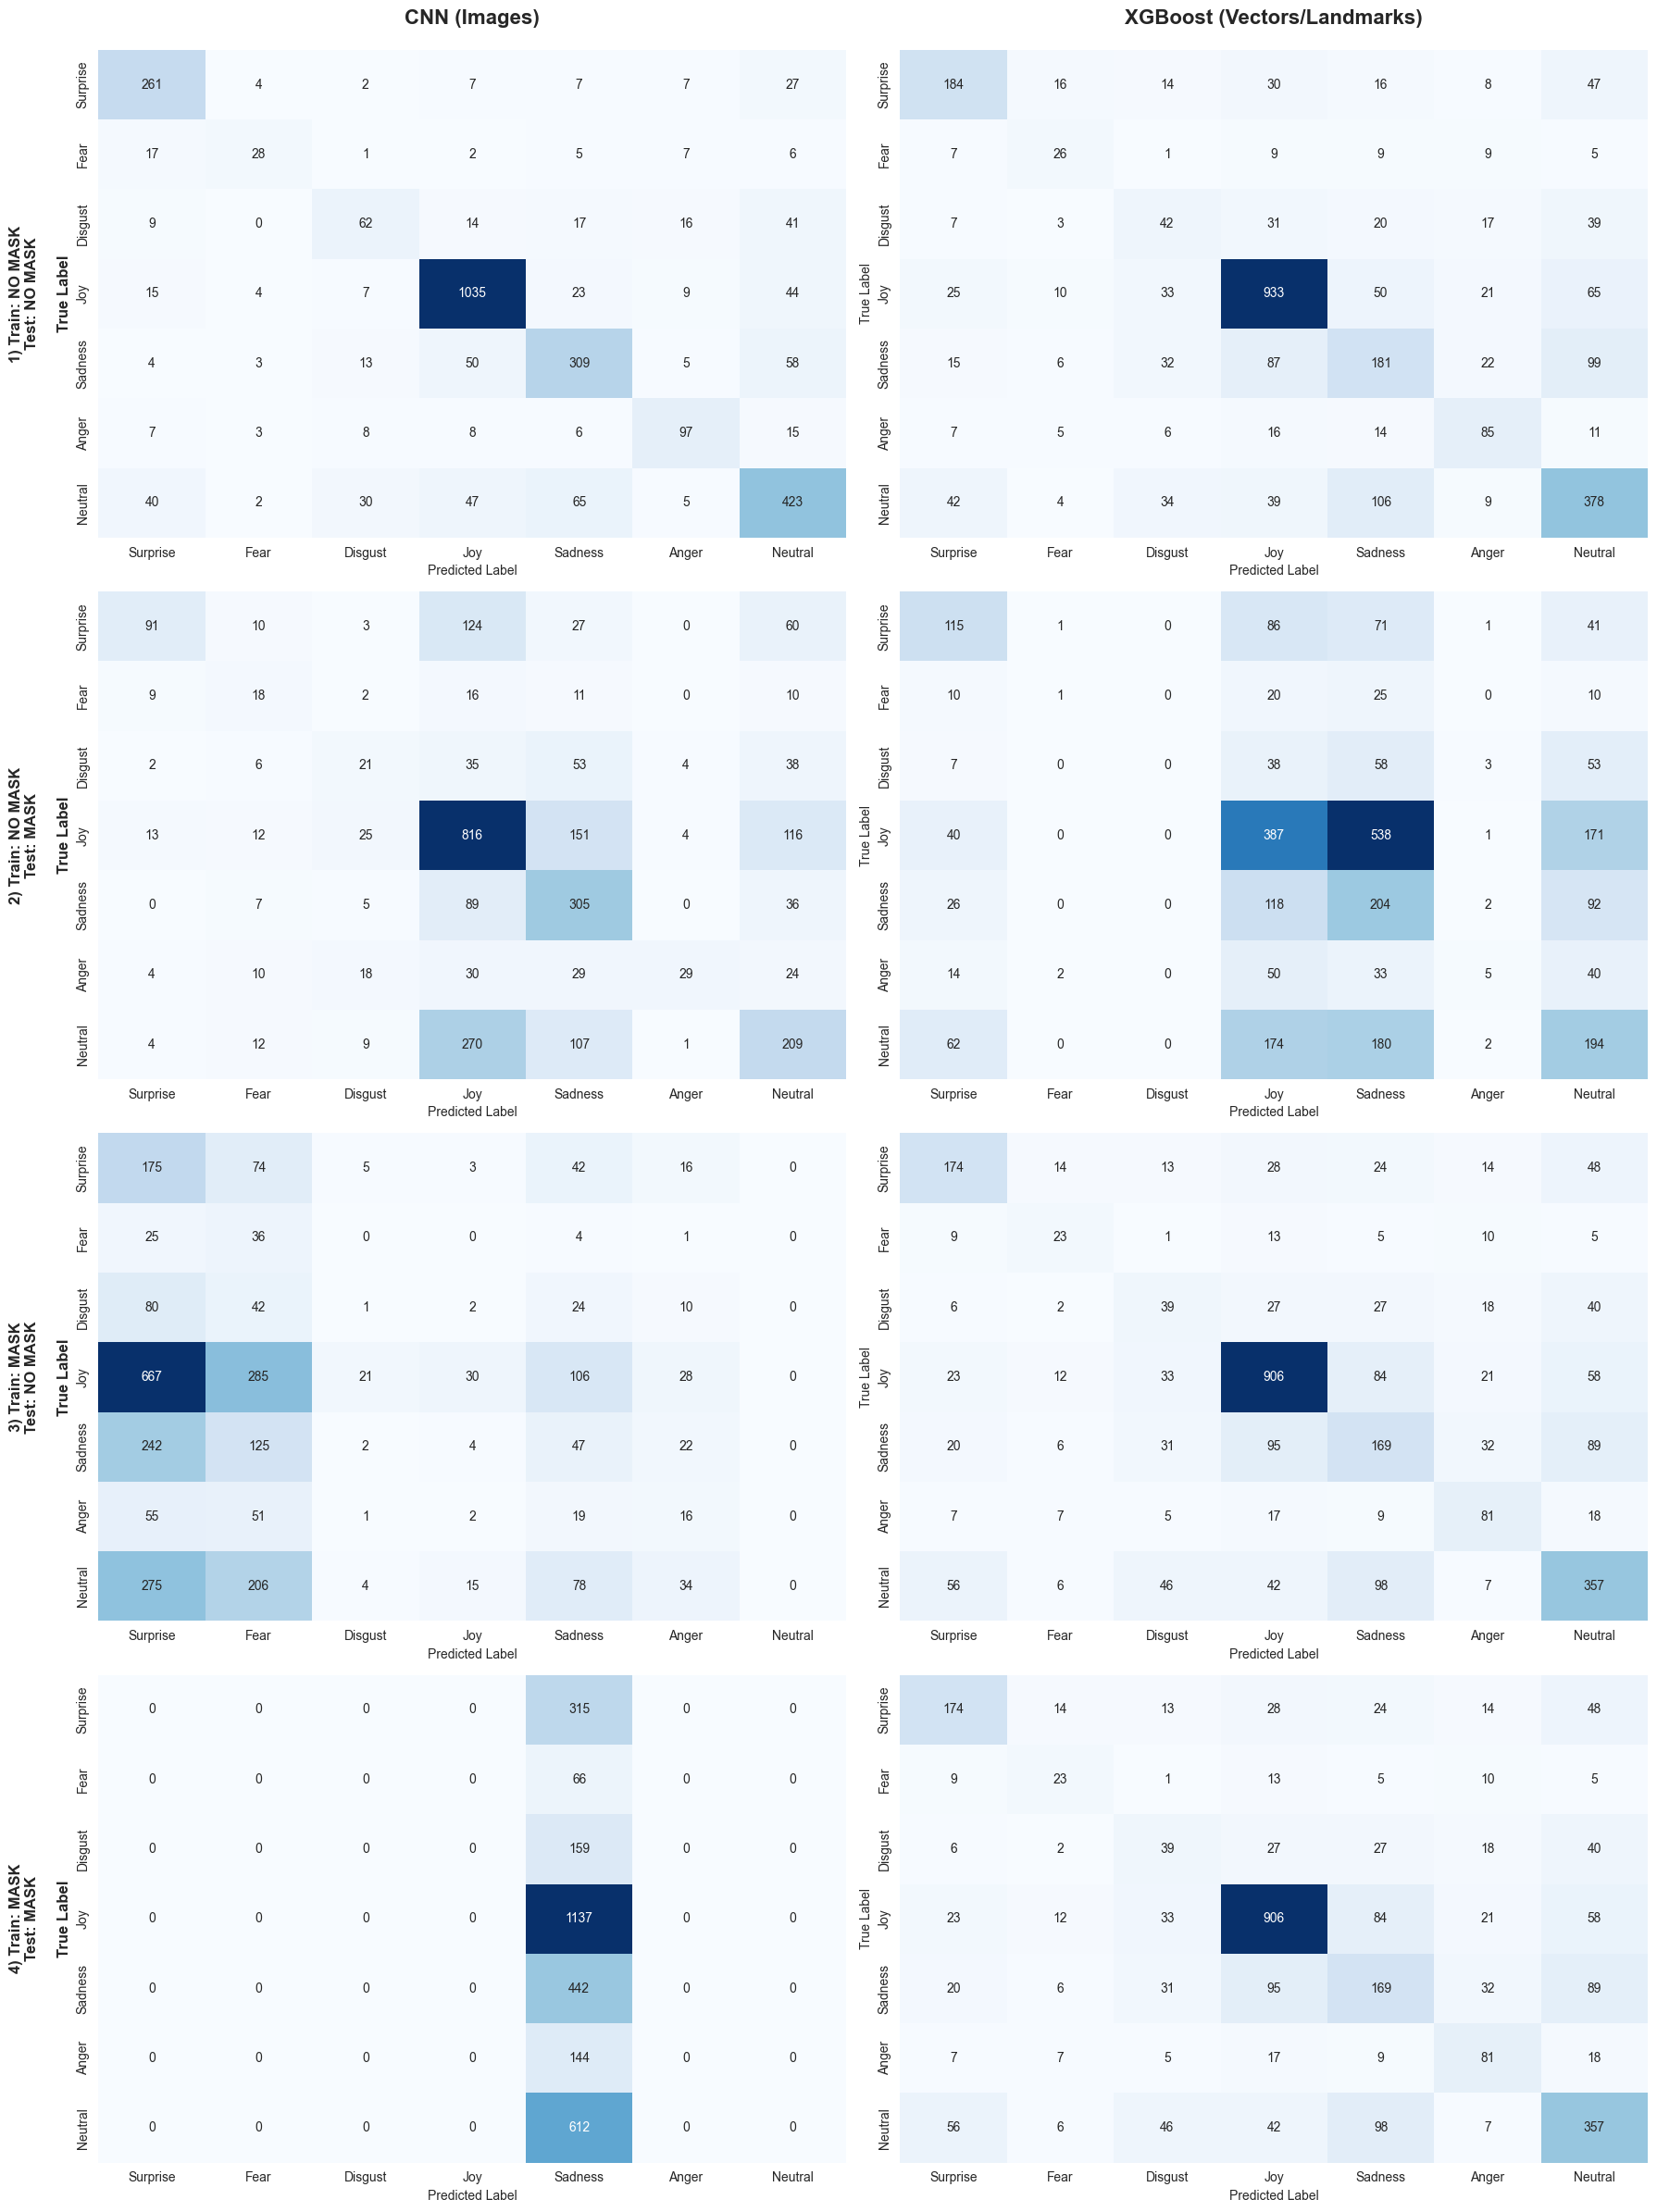

In [7]:
plot_mapping = {
    # 1) train: no_mask -> test: no_mask
    ("CNN NO MASK", "Img Test NO MASK"): (0, 0),
    ("XGBoost NO MASK", "CSV Test NO MASK"): (0, 1),
    # 2) train: no_mask -> test: mask
    ("CNN NO MASK", "Img Test WITH MASK"): (1, 0),
    ("XGBoost NO MASK", "CSV Test WITH MASK"): (1, 1),
    # 3) train: mask -> test: no_mask
    ("CNN MASK", "Img Test NO MASK"): (2, 0),
    ("XGBoost MASK", "CSV Test NO MASK"): (2, 1),
    # 4) train: mask -> test: mask
    ("CNN MASK", "Img Test WITH MASK"): (3, 0),
    ("XGBoost MASK", "CSV Test WITH MASK"): (3, 1),
}
row_titles = [
    "1) Train: NO MASK\nTest: NO MASK",
    "2) Train: NO MASK\nTest: MASK",
    "3) Train: MASK\nTest: NO MASK",
    "4) Train: MASK\nTest: MASK"
]
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 24))
axes[0, 0].set_title("CNN (Images)", fontsize=16, pad=20, fontweight='bold')
axes[0, 1].set_title("XGBoost (Vectors/Landmarks)", fontsize=16, pad=20, fontweight='bold')
for res in results_data:
    key = (res["Model"], res["Dataset"])
    if key in plot_mapping:
        row, col = plot_mapping[key]
        ax = axes[row, col]
        cm = res["CM"]
        sns.heatmap(cm, ax=ax, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        ax.set_xlabel('Predicted Label')
        if col == 0:
            ax.set_ylabel(f"{row_titles[row]}\n\nTrue Label", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

## SHAP Exploration for CNN

PartitionExplainer explainer: 9it [00:15,  3.77s/it]                       


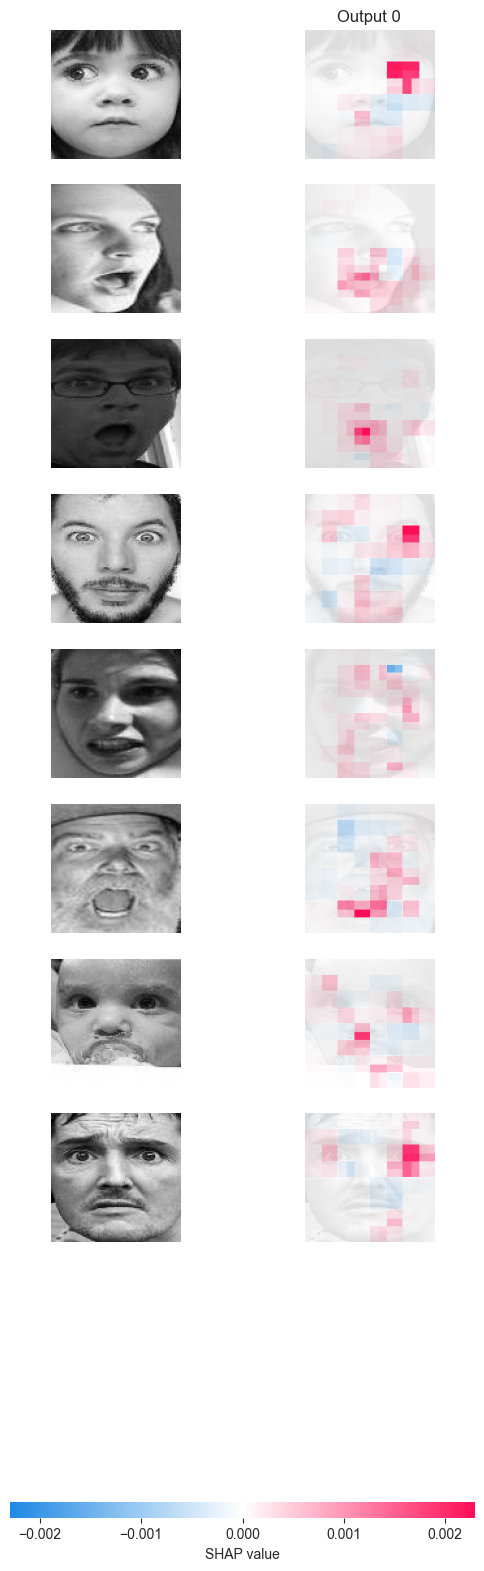

In [10]:
masker = shap.maskers.Image("blur(100,100)", X_nomask_img[0].shape)
explainer = shap.Explainer(model_cnn_no_mask, masker)
test_images = X_nomask_img[0:8]
shap_values = explainer(
    test_images, 
    max_evals=500, 
    batch_size=50, 
    outputs=shap.Explanation.argsort.flip[:1]
)
shap.image_plot(shap_values)

## XGBoost Vector Visualization

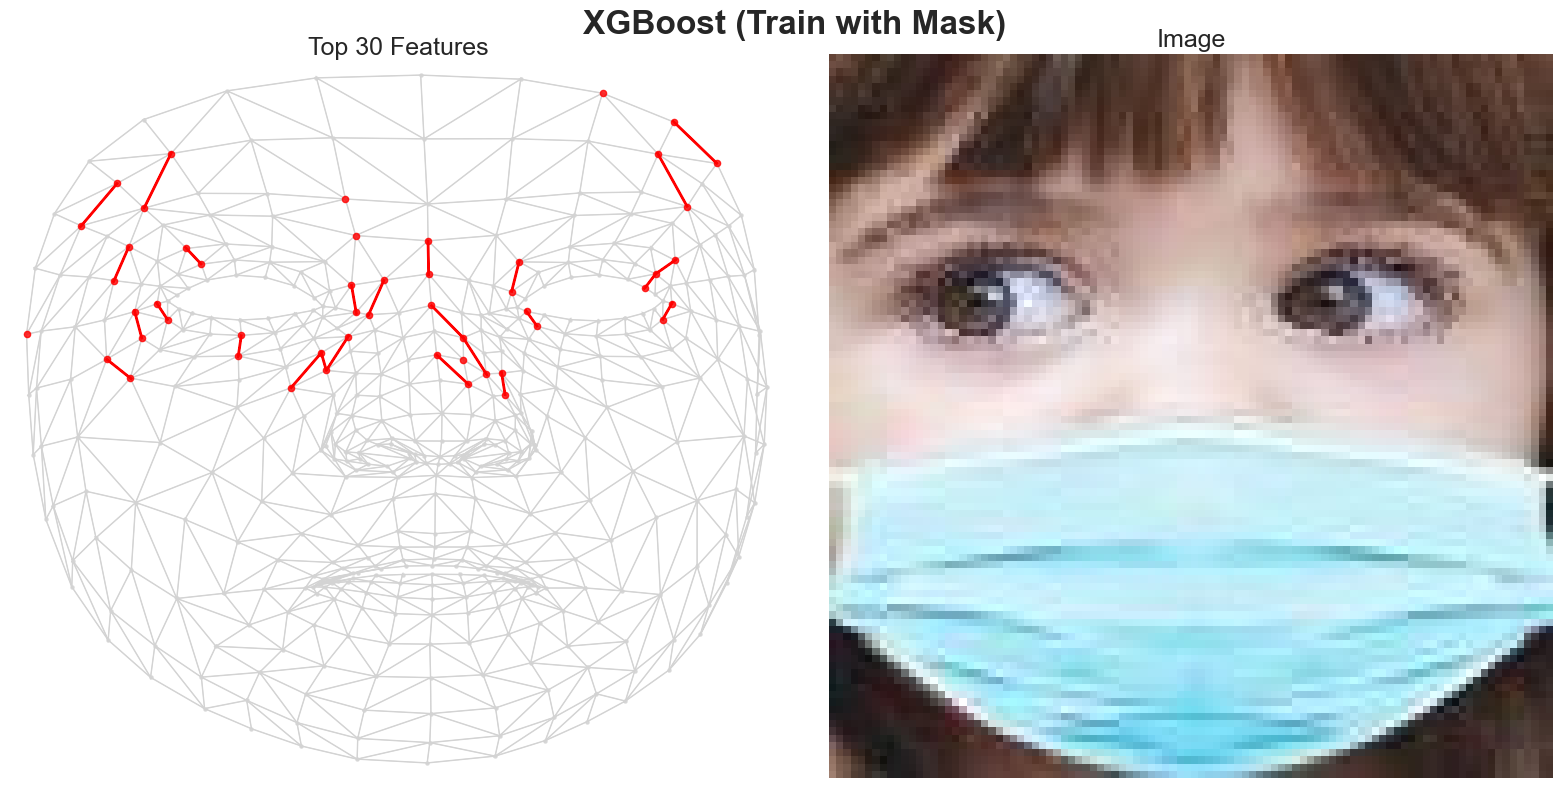

In [11]:
# === Feature Importance Extraction ===
importances = model_xgb_mask.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feats_mask,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
top_30_df = importance_df.head(30)
top_edges = set()
top_landmarks = set()
# === Parsing Top 30 Features (Edges and Landmarks) ===
for feat in top_30_df['Feature']:
    if feat.startswith('edge_'):
        top_edges.add(feat)
        match = re.match(r'edge_(\d+)_(\d+)', feat)
        if match:
            top_landmarks.add(int(match.group(1)))
            top_landmarks.add(int(match.group(2)))
    elif feat.startswith('landmark_'):
        match = re.match(r'landmark_(\d+)_', feat)
        if match:
            top_landmarks.add(int(match.group(1)))
# === Data Loading ===
IMG_WITH_MASK_PATH = 'DATA/IMAGES/WITH MASK/test/1/test_0002_aligned.jpg'
df = pd.read_csv(PATH_TEST_NOMASK_CSV)
row = df.iloc[0]
landmarks = np.array([
    [row[f'landmark_{i}_x'], row[f'landmark_{i}_y']] for i in range(468)
])
# === Plot Setup ===
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('XGBoost (Train with Mask)', fontsize=24, fontweight='bold')
ax_viz = axes[0]
# === Drawing Landmarks ===
for i, (x, y) in enumerate(landmarks):
    is_top = i in top_landmarks
    color = 'red' if is_top else 'lightgray'
    size = 20 if is_top else 5
    zord = 5 if is_top else 2
    ax_viz.scatter(x, -y, s=size, c=color, alpha=0.8, zorder=zord)
# === Drawing Edges ===
edge_cols = [c for c in df.columns if c.startswith('edge_')]
pattern = re.compile(r'edge_(\d+)_(\d+)')
for edge in edge_cols:
    match = pattern.match(edge)
    if not match:
        continue
    idx1, idx2 = int(match.group(1)), int(match.group(2))
    p1, p2 = landmarks[idx1], landmarks[idx2]
    x1, y1 = p1[0], -p1[1]
    x2, y2 = p2[0], -p2[1]
    dx = x2 - x1
    dy = y2 - y1
    is_top_edge = edge in top_edges
    color = 'red' if is_top_edge else 'lightgray'
    lw = 1.5 if is_top_edge else 0.5
    zord = 4 if is_top_edge else 1
    ax_viz.arrow(
        x1, y1, dx, dy,
        head_width=0.001,
        head_length=0.003,
        fc=color, ec=color, linewidth=lw, zorder=zord
    )
# === Formatting the Vector Subplot ===
ax_viz.set_xlim(-0.1, 1)
ax_viz.set_ylim(-1, 0)
ax_viz.set_title("Top 30 Features", fontsize=18)
ax_viz.set_aspect('equal')
ax_viz.axis('off')
# === Drawing the Image Subplot ===
ax_img2 = axes[1]
img2 = mpimg.imread(IMG_WITH_MASK_PATH)
ax_img2.imshow(img2)
ax_img2.set_title("Image", fontsize=18)
ax_img2.axis('off')
# === Render Plot ===
plt.tight_layout()
plt.show()